In [1]:
import os
os.chdir(r"..\models\..")

import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import torch.nn.functional as F
import pickle

from tokenizer import Tokenizer
from sentiment_classifier import SentimentClassifier

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset, DataLoader

In [2]:
# Getting Sources / Data
sources = [
    "data/amazon_cells_labelled.txt",
    "data/imdb_labelled.txt",
    "data/yelp_labelled.txt"
]

# Loading Dataset
def load_dataset(sources):
    texts = []
    labels = []

    for source in sources:
        with open(source, "r", encoding="utf8") as f:

            for line in f:
                if "\t" not in line:
                    continue

                text, label = line.strip().split("\t")
                texts.append(text)
                labels.append(int(label))

    return texts, labels

texts, labels = load_dataset(sources)

In [3]:
# Splitting texts for Training
train_texts, val_texts, train_labels, val_labels = train_test_split(
    texts, labels, test_size=0.2, random_state=42)

# Tokenizing the Text
tokenizer = Tokenizer(vocab_size=100_000)

tokenizer.fit(train_texts)  # learns vocabulary

with open("models/classification_tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

In [4]:
train_tokens = [tokenizer.transform(text) for text in train_texts]
val_tokens = [tokenizer.transform(text) for text in val_texts]

MAX_LEN = max(len(seq) for seq in train_tokens + val_tokens)

X_train = tokenizer.pad_sequence(train_tokens, max_len=MAX_LEN)
X_val   = tokenizer.pad_sequence(val_tokens, max_len=MAX_LEN)

X_train = torch.tensor(X_train, dtype=torch.long)
X_val   = torch.tensor(X_val, dtype=torch.long)

y_train = torch.tensor(train_labels, dtype=torch.long)
y_val   = torch.tensor(val_labels, dtype=torch.long)

batch_size = 16

train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = SentimentClassifier(
    vocab_size=10_000,
    embedding_dim=512,
    num_layers=3,
    num_heads=4,
    d_ff=2048,
    max_len=MAX_LEN,
    num_classes=2,
    dropout=0.3,
    device=device).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=2e-4)

In [6]:
# Plotting Metrics Function
def plot_metrics(train_losses, val_accuracies, train_accuracies=None):
    epochs = range(1, len(val_accuracies) + 1)

    plt.figure(figsize=(12, 5))

    # Loss Plotting
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_losses, label="Train Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training Loss")
    plt.grid()
    plt.legend()

    # Accuracy Plotting
    plt.subplot(1, 2, 2)
    plt.plot(epochs, val_accuracies, label="Validation Accuracy")
    if train_accuracies:
        plt.plot(epochs, train_accuracies, label="Train Accuracy")

    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Accuracy")
    plt.grid()
    plt.legend()
    
    plt.tight_layout()
    plt.show()

In [7]:
# Evaluation
def evaluate(model, loader, device):
    model.eval()
    correct = 0

    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        outputs = model(X_batch)
        preds = outputs.argmax(dim=1)
        correct += (preds == y_batch).sum().item()

    return correct / len(loader.dataset)

# Training Loop
def train(model, train_loader, val_loader, criterion, optimizer, device, epochs=20, patience=4):

    best_val_acc = 0
    patience_counter = 0

    train_losses = []
    val_accuracies = []
    train_accuracies = []

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        correct = 0
        total = 0

        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            optimizer.zero_grad()
            outputs = model(X_batch)

            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * X_batch.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == y_batch).sum().item()
            total += y_batch.size(0)

        avg_loss = total_loss  / total
        train_acc = correct / len(train_loader.dataset)
        val_acc = evaluate(model, val_loader, device)

        train_losses.append(total_loss / len(train_loader))
        val_accuracies.append(val_acc)
        train_accuracies.append(train_acc)
            
        print(f"Epoch {epoch+1}: Average Loss = {avg_loss:.4f}, Train Accuracy = {100*train_acc:.2f}%, Validation Accuracy = {100*val_acc:.2f}%")

        # Early Stopping and Checkpointing
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            patience_counter = 0
            torch.save({
                "model_state_dict": model.state_dict(),
                "max_len": MAX_LEN,
            }, "models/classification_best_model.pt")

        else:
            patience_counter += 1

        if patience_counter >= patience:
            print(f"Early stopping was trigged at {epoch+1}")
            break

    plot_metrics(train_losses, val_accuracies, train_accuracies)


CUDA available: True
CUDA device name: NVIDIA GeForce GTX 1660
Epoch 1: Average Loss = 0.7092, Train Accuracy = 54.37%, Validation Accuracy = 65.00%
Epoch 2: Average Loss = 0.5920, Train Accuracy = 68.29%, Validation Accuracy = 73.17%
Epoch 3: Average Loss = 0.5167, Train Accuracy = 75.46%, Validation Accuracy = 78.17%
Epoch 4: Average Loss = 0.4828, Train Accuracy = 76.50%, Validation Accuracy = 74.67%
Epoch 5: Average Loss = 0.4388, Train Accuracy = 80.25%, Validation Accuracy = 76.50%
Epoch 6: Average Loss = 0.4090, Train Accuracy = 81.79%, Validation Accuracy = 76.50%
Epoch 7: Average Loss = 0.3881, Train Accuracy = 83.42%, Validation Accuracy = 78.67%
Epoch 8: Average Loss = 0.3724, Train Accuracy = 83.92%, Validation Accuracy = 77.50%
Epoch 9: Average Loss = 0.3702, Train Accuracy = 85.21%, Validation Accuracy = 79.33%
Epoch 10: Average Loss = 0.3383, Train Accuracy = 85.92%, Validation Accuracy = 78.00%
Epoch 11: Average Loss = 0.3235, Train Accuracy = 86.71%, Validation Accura

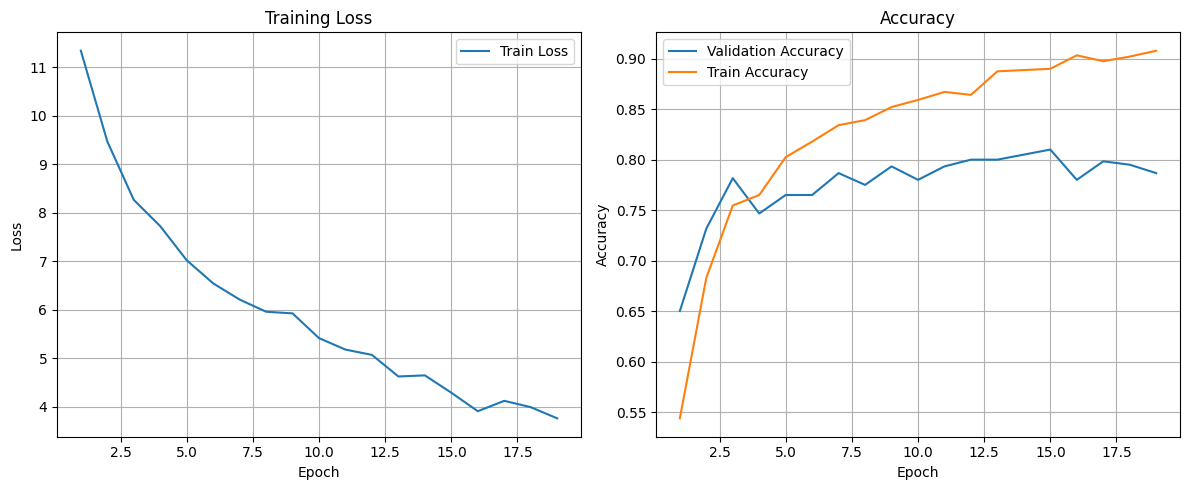

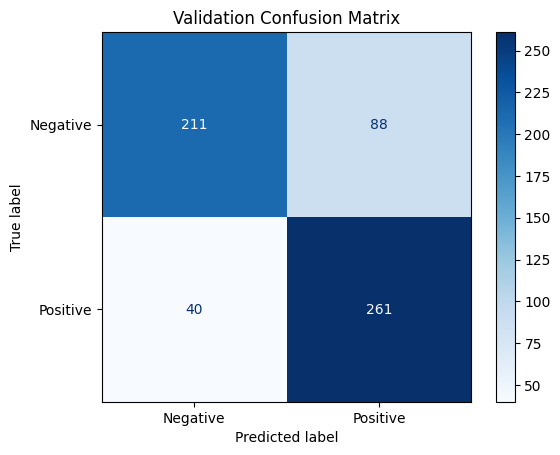

In [8]:
print("\nCUDA available:", torch.cuda.is_available())
print("CUDA device name:", torch.cuda.get_device_name(torch.cuda.current_device()))
train(model, train_loader, val_loader, criterion, optimizer, device, epochs=20)

# Confusion Matrix (True Positives, False Negatives, etc)
y_true = []
y_pred = []

for X_batch, y_batch in val_loader:
    with torch.no_grad():
        outputs = model(X_batch.to(device))
        preds = outputs.argmax(dim=1).cpu()
        y_true.extend(y_batch.cpu())
        y_pred.extend(preds)

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Negative", "Positive"])
disp.plot(cmap="Blues")
plt.title('Validation Confusion Matrix')
plt.show()

In [9]:
# Tryin Model
# Tokenizer
with open("models/classification_tokenizer.pkl", "rb") as f:
    tokenizer = pickle.load(f)

# Model parameters
vocab_size = 10_000
embedding_dim = 512
num_layers = 3
num_heads = 4
d_ff = 2048
num_classes = 2  # positive vs negative
dropout = 0.3
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Loading the trained model
checkpoint = torch.load("models/classification_best_model.pt")
max_len = checkpoint["max_len"]

model = SentimentClassifier(
    vocab_size=vocab_size,
    embedding_dim=embedding_dim,
    num_layers=num_layers,
    num_heads=num_heads,
    d_ff=d_ff,
    max_len=max_len,
    num_classes=num_classes,
    dropout=dropout,
    device=device).to(device)

# Load the model state
model.load_state_dict(checkpoint["model_state_dict"])

label_map = {0: "Negative", 1: "Positive"}

def predict_sentiment(sentence, model, tokenizer, max_len, device="cuda"):
    model.eval()

    with torch.no_grad():
        tokens = tokenizer.transform(sentence)
        tokens = tokenizer.pad_sequence([tokens], max_len)
        input_tensor = torch.tensor(tokens, dtype=torch.long).to(device)

        logits = model(input_tensor)

        probs = F.softmax(logits, dim=1)
        prediction = torch.argmax(probs, dim=1).item()
        confidence = probs[0][prediction].item()
    
        return print(f"{sentence} = {label_map[prediction]}, {confidence:.2f}")

examples = ["I love you!",
            "I can't believe it",
            "I hate this movie so much!", 
            "I think this was wonderful!",
            "Worst experience of my entire life",
            "I don't love you anymore"]

for example in examples:
    predict_sentiment(example, model, tokenizer, max_len)

I love you! = Positive, 1.00
I can't believe it = Negative, 0.90
I hate this movie so much! = Negative, 1.00
I think this was wonderful! = Positive, 1.00
Worst experience of my entire life = Negative, 1.00
I don't love you anymore = Negative, 0.59
